# 1. The Physics: Nonlinear Heat Equation
We are solving for the temperature evolution $T(x, t)$ over a 1D domain where the thermal conductivity is both spatially varying ($\alpha(x)$) and temperature-dependent ($T^2$):

$$\rho c_p \frac{\partial T}{\partial t} = \frac{\partial}{\partial x} \left( k(x, T) \frac{\partial T}{\partial x} \right)$$

Where $k(x, T) = \alpha(x) \cdot (0.5 + T^2)$. This nonlinearity makes the problem challenging for standard linear solvers.

# 2. Finite Element Method (FEM) Solver
The FEM discretization converts the continuous PDE into a system of algebraic equations.

* **Spatial Discretization:** The domain is divided into $N$ elements. We use linear basis functions to build the Stiffness Matrix ($K$) representing conduction and the Mass Matrix ($M$) representing heat capacity.
* **Time Stepping:** We use the Backward Euler scheme (implicit) for stability:

$$(M + \Delta t K) T_{n+1} = M T_n$$

* **Data Generation:** The code generates trajectories by varying the material property profile $\alpha(x)$ and the initial temperature $T_0$ using random sine waves and step functions.

# 3. Fourier Neural Operator (FNO)
Unlike standard CNNs that learn pixel-to-pixel mappings, the FNO learns the Operator (the mapping between function spaces).

### The Spectral Layer Formula
The core of the FNO is the spectral convolution. It transforms the input to the frequency domain, filters out high-frequency noise, and transforms it back:

$$\text{Output} = \sigma \left( \mathcal{F}^{-1} (R \cdot \mathcal{F}(x)) + Wx \right)$$

* $\mathcal{F}$: Fast Fourier Transform (FFT).
* $R$: Learnable weights in the Fourier space (truncated to the first $k$ modes).
* $W$: A linear skip connection (residual) to preserve spatial features.
* $\sigma$: Activation function (GELU).

# 4. Code Architecture Walkthrough

### I. Data Generation (`solve_transient_fem_step`)
This block handles the "heavy lifting" of the physics. It assembles the global $K$ and $M$ matrices for every time step because the conductivity $k$ changes as the temperature $T$ evolves.

### II. The Model (`fno_model`)
The FNO takes a 3-channel input:
1. Current Temperature ($T_n$)
2. Material Properties ($\alpha(x)$)
3. Spatial Grid ($x$)

It predicts the Residual (the change in temperature), which is then added to $T_n$ to get $T_{n+1}$.

### III. Training & Rollout
The model is trained using AdamW optimization on the Mean Squared Error (MSE) between the FEM prediction and the FNO prediction. During "Rollout," we feed the model's own output back as the next input to simulate a full time-trajectory.

### Model Specifications

| Feature | Specification | Description |
| :--- | :--- | :--- |
| **Epochs** | 5001 | Number of training iterations. |
| **FNO Layers** | 4 Spectral Layers | Depth of the operator network. |
| **Modes** | 6 | Number of Fourier frequencies retained. |
| **Width** | 64 | Hidden channels (dimensionality) of the layers. |
| **Batch Size** | 32 | Number of samples per gradient update. |
| **Learning Rate** | 8e-4 | Step size for the AdamW optimizer. |
| **Weight Decay** | 1e-4 | Regularization to prevent overfitting. |
| **Activation** | GELU | Non-linear activation function. |
| **Residual Prep** | $T_{curr} + (\text{Res} \cdot \text{Mask})$ | The model predicts the change in temperature. |

In [9]:
%%writefile config.py
import jax.numpy as jnp

N_GRID = 64
N_NODES = N_GRID + 1
WIDTH = 64
MODES = 8        
BATCH_SIZE = 32
EPOCHS = 10001    
N_SAMPLES = 1000 
TRAIN_SAMPLES = 800
MAX_STEPS = 20
DT = 0.02
RHO_CP = 5.0
GRID = jnp.linspace(0, 1, N_NODES)

Overwriting config.py


In [ ]:
%%writefile physics.py
import jax
import jax.numpy as jnp
from config import N_GRID, N_NODES, RHO_CP, DT, MAX_STEPS

@jax.jit
def generate_smooth_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2 = jax.random.split(key, 2)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    return jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)

@jax.jit
def generate_complex_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2, k3, k4 = jax.random.split(key, 4)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    smooth = jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)
    edge_pos = jax.random.uniform(k3, (), minval=0.2, maxval=0.8)
    edge_height = jax.random.uniform(k4, (), minval=-0.3, maxval=0.3)
    sharp = jnp.where(x < edge_pos, edge_height, 0.0)
    return smooth + sharp

@jax.jit
def solve_transient_fem_step(T_n, alpha_x):
    dx = 1.0 / N_GRID
    K_mat = jnp.zeros((N_NODES, N_NODES))
    M_mat = jnp.zeros((N_NODES, N_NODES))
    k_nodal = alpha_x * (0.5 + T_n**2)
    for e in range(N_GRID):
        ix = jnp.array([e, e + 1])
        k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
        ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
        me = (RHO_CP * dx / 6.0) * jnp.array([[2.0, 1.0], [1.0, 2.0]])
        K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
        M_mat = M_mat.at[jnp.ix_(ix, ix)].add(me)
    LHS = M_mat + DT * K_mat
    RHS = M_mat @ T_n
    free = jnp.arange(1, N_NODES - 1)
    RHS_free = RHS[free] - LHS[free, 0] * 1.0 - LHS[free, -1] * 0.0
    T_next_free = jnp.linalg.solve(LHS[jnp.ix_(free, free)], RHS_free)
    return jnp.zeros(N_NODES).at[0].set(1.0).at[-1].set(0.0).at[free].set(T_next_free)

@jax.jit
def generate_trajectory(key_k, key_t):
    alpha = jax.nn.sigmoid(generate_smooth_fn(key_k)) * 0.4 + 0.1
    T0_signal = generate_complex_fn(key_t)
    ramp = jnp.linspace(1.0, 0.0, N_NODES)
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, N_NODES))
    T0 = ramp + (T0_signal * mask)
    def step_fn(T_curr, _):
        T_next = solve_transient_fem_step(T_curr, alpha)
        return T_next, (T_curr, T_next)
    _, (inputs, targets) = jax.lax.scan(step_fn, T0, None, length=MAX_STEPS-1)
    return inputs, targets, alpha, T0

def fem_rollout(T_init, alpha_prof, steps):
    def step(T_curr, _): 
        val = solve_transient_fem_step(T_curr, alpha_prof)
        return val, val
    return jnp.vstack([T_init, jax.lax.scan(step, T_init, None, length=steps)[1]])

Overwriting physics.py


In [ ]:
%%writefile model.py
import jax
import jax.numpy as jnp
from config import WIDTH, MODES, N_NODES

def spectral_layer(x, w_spec, w_skip:
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:MODES].set(
        jnp.einsum('mi, mij -> mj', x_ft[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(params, x_norm, T_curr):
    x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
    for i in range(2, 10, 2):
        x = spectral_layer(x, params[i], params[i+1])
    x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
    res = (jnp.dot(x, params[12]) + params[13]).squeeze()
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, N_NODES))
    return T_curr + (res * mask)

def init_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (3, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i+5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH), 
              norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
    return p

Overwriting model.py


In [44]:
%%writefile plotting.py
import matplotlib.pyplot as plt
import numpy as np
from config import GRID, MAX_STEPS

def plot_results(epochs_recorded, train_loss_history, val_loss_history, true_traj, fno_traj, abs_error, T0_test):
    plt.rcParams.update({'font.size': 11})
    
    # Create a figure with a 2-row, 1-column grid layout
    fig = plt.figure(figsize=(10, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.1])

    # ==========================================
    # ROW 1: Training & Validation Convergence 
    # ==========================================
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(epochs_recorded, train_loss_history, color='#2c3e50', lw=2, label='Train Loss (Batch)')
    ax0.plot(epochs_recorded, val_loss_history, color='#e74c3c', lw=2, ls='--', label='Validation Loss (Unseen)')
    ax0.set_yscale('log')
    ax0.set_title("Training & Validation Convergence", fontweight='bold', fontsize=14, pad=10)
    ax0.set_xlabel("Actual Epochs")
    ax0.set_ylabel("Loss (MSE)")
    ax0.grid(True, which="both", ls="-", alpha=0.2)
    ax0.legend(loc='upper right')

    # Time and Grid extensions for 2D plotting
    time_steps = np.arange(MAX_STEPS)
    T, X = np.meshgrid(time_steps, GRID)

    # ==========================================
    # ROW 2: Space-Time Rollout Trajectories
    # ==========================================
    # Absolute Error Only
    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.imshow(abs_error.T, aspect='auto', origin='lower', cmap='inferno',
                     extent=[0, MAX_STEPS-1, 0, 1])
    ax3.set_title("Absolute Prediction Error", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Grid (x)")
    fig.colorbar(im3, ax=ax3, label="Error Magnitude")

    plt.tight_layout()
    plt.show()

Overwriting plotting.py


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Generating FEM Data...
Training for 10001 epochs...
Epoch    0 | Train MSE: 1.162606e-04 | Val MSE: 6.590419e-04
Epoch 1000 | Train MSE: 5.311462e-06 | Val MSE: 1.295997e-05
Epoch 2000 | Train MSE: 6.413265e-06 | Val MSE: 1.178612e-05
Epoch 3000 | Train MSE: 3.969034e-06 | Val MSE: 5.669342e-06
Epoch 4000 | Train MSE: 4.115972e-06 | Val MSE: 3.980495e-06
Epoch 5000 | Train MSE: 4.504886e-06 | Val MSE: 3.081152e-06
Epoch 6000 | Train MSE: 3.765703e-06 | Val MSE: 2.863369e-06
Epoch 7000 | Train MSE: 1.673361e-06 | Val MSE: 2.288246e-06
Epoch 8000 | Train MSE: 3.234693e-06 | Val MSE: 2.077889e-06
Epoch 9000 | Train MSE: 7.696448e-07 | Val MSE: 1.988499e-06
Epoch 10000 | Train MSE: 1.370454e-06 | Val MSE: 1.944251e-06


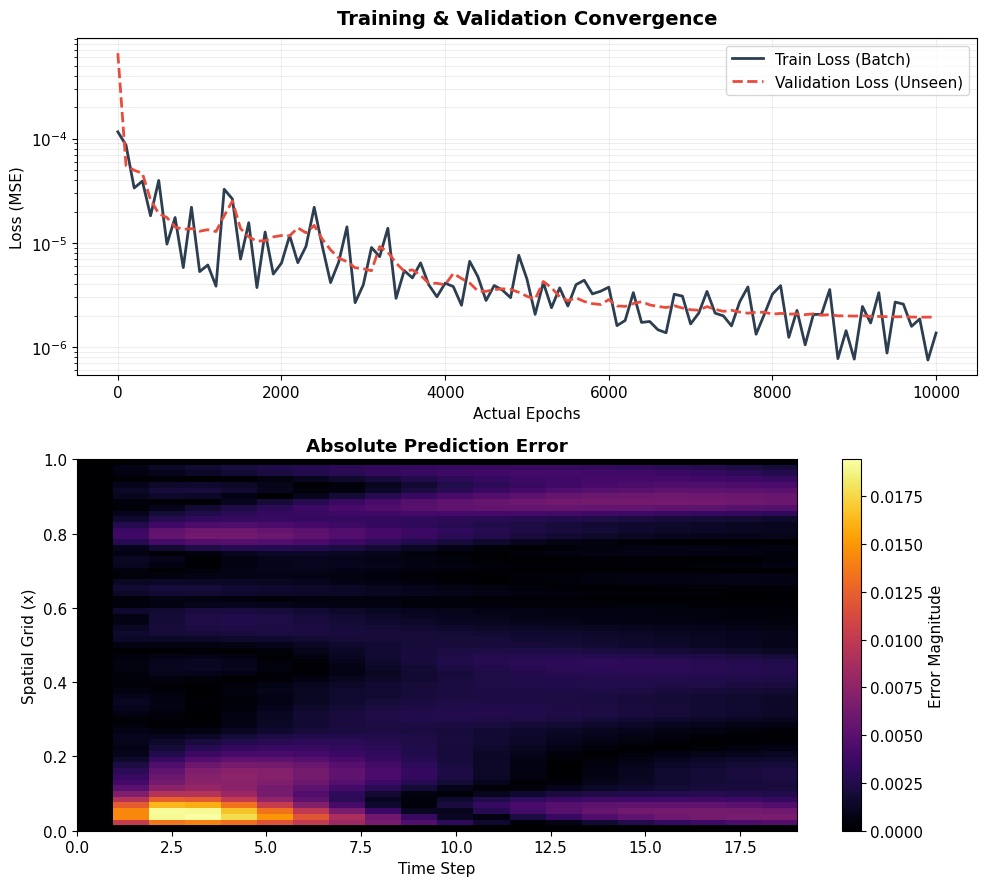

In [45]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import optax
from config import *
import physics
import model
import plotting

# 1. GENERATE DATA
print("Generating FEM Data...")
keys_k = jax.random.split(jax.random.PRNGKey(42), N_SAMPLES)
keys_t = jax.random.split(jax.random.PRNGKey(7), N_SAMPLES)
all_X_T, all_Y_T, all_Alpha, all_T0 = jax.vmap(physics.generate_trajectory)(keys_k, keys_t)

# 2. DATA PREPARATION (Train & Validation Splits)
VAL_SAMPLES = 100  # Allocate 100 unseen trajectories for validation

grid_expanded = jnp.tile(GRID, (N_SAMPLES, MAX_STEPS-1, 1))
X_raw = jnp.stack([all_X_T, jnp.tile(all_Alpha[:, None, :], (1, MAX_STEPS-1, 1)), grid_expanded], axis=-1)
Y_raw = all_Y_T[..., None]

# Train Set
X_train_flat = X_raw[:TRAIN_SAMPLES].reshape(-1, N_NODES, 3)
Y_train_flat = Y_raw[:TRAIN_SAMPLES].reshape(-1, N_NODES, 1)

# Validation Set (In-Distribution, Unseen during training)
X_val_flat = X_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].reshape(-1, N_NODES, 3)
Y_val_flat = Y_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].reshape(-1, N_NODES, 1)

# Normalization based strictly on training statistics
x_mean, x_std = X_train_flat.mean(axis=(0, 1)), X_train_flat.std(axis=(0, 1)) + 1e-7
X_train_norm = (X_train_flat - x_mean) / x_std
X_val_norm = (X_val_flat - x_mean) / x_std

# 3. TRAINING SETUP
params = model.init_params(jax.random.PRNGKey(123))
lr_schedule = optax.cosine_decay_schedule(
    init_value=1e-3, 
    decay_steps=EPOCHS, 
    alpha=1e-2
)

optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)
opt_state = optimizer.init(params)

@jax.jit
def train_step(p, opt_s, b_X_norm, b_X_raw, b_Y):
    T_curr_batch = b_X_raw[:, :, 0]
    loss_fn = lambda p: jnp.mean((jax.vmap(model.fno_model, (None, 0, 0))(p, b_X_norm, T_curr_batch) - b_Y.squeeze())**2)
    l, g = jax.value_and_grad(loss_fn)(p)
    u, opt_s = optimizer.update(g, opt_s, p)
    return optax.apply_updates(p, u), opt_s, l

# Dedicated evaluation function for validation tracking
@jax.jit
def evaluate_loss(p, b_X_norm, b_X_raw, b_Y):
    T_curr_batch = b_X_raw[:, :, 0]
    preds = jax.vmap(model.fno_model, (None, 0, 0))(p, b_X_norm, T_curr_batch)
    return jnp.mean((preds - b_Y.squeeze())**2)

# Metrics history tracking arrays
loss_history = []
val_history = []
epochs_recorded = []

print(f"Training for {EPOCHS} epochs...")
for i in range(EPOCHS):
    idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, X_train_flat.shape[0])
    params, opt_state, loss = train_step(params, opt_state, X_train_norm[idx], X_train_flat[idx], Y_train_flat[idx])
    
    if i % 100 == 0:
        val_loss = evaluate_loss(params, X_val_norm, X_val_flat, Y_val_flat)
        loss_history.append(float(loss))
        val_history.append(float(val_loss))
        epochs_recorded.append(i)  # Captures actual epoch index
        
    if i % 1000 == 0: 
        print(f"Epoch {i:4d} | Train MSE: {loss:.6e} | Val MSE: {val_loss:.6e}")

# 4. ROLLOUT EVALUATION (On a single unseen target test profile)
test_idx = TRAIN_SAMPLES + VAL_SAMPLES + 5
T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]

def rollout_fno(p, T_init, alpha_prof, steps):
    def step(T_curr, _):
        x_norm = (jnp.stack([T_curr, alpha_prof, GRID], axis=-1) - x_mean) / x_std
        T_next = model.fno_model(p, x_norm, T_curr)
        return T_next, T_next
    return jax.lax.scan(step, T_init, None, length=steps)[1]

true_traj = physics.fem_rollout(T0_test, alpha_test, MAX_STEPS-1)
fno_traj = jnp.vstack([T0_test, rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)])
abs_error = jnp.abs(true_traj - fno_traj)

# 5. VISUALIZE
plotting.plot_results(epochs_recorded, loss_history, val_history, true_traj, fno_traj, abs_error, T0_test)

Computing full rollout errors for all samples...


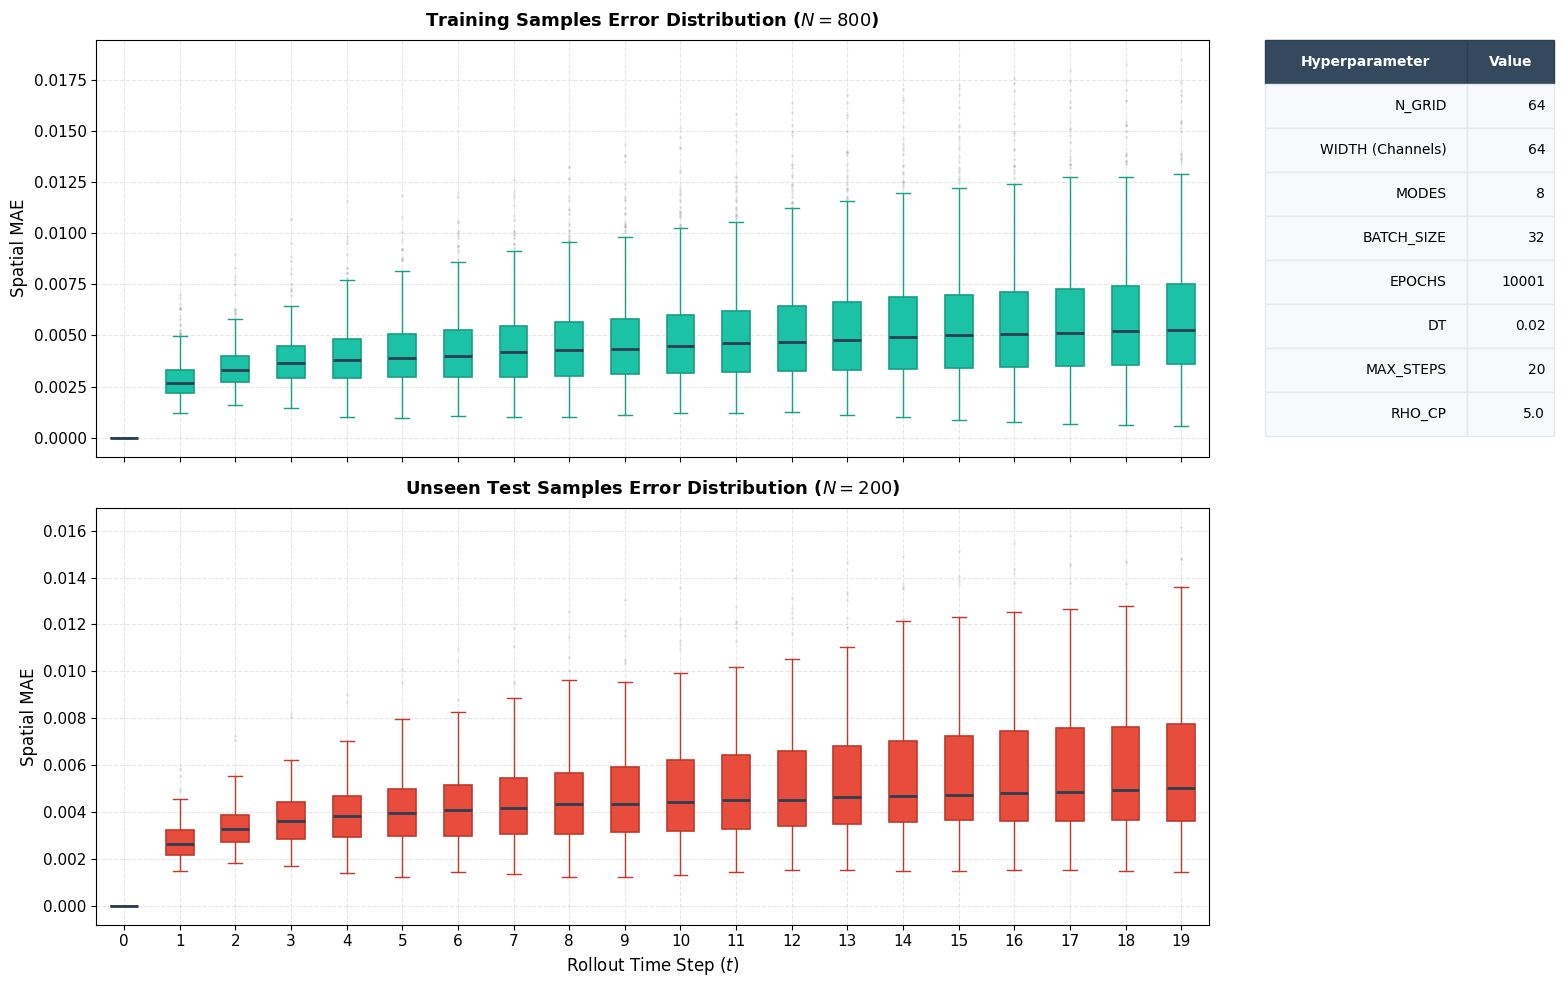

In [14]:
# =====================================================================
# 1. COMPUTE BATCHED ROLLOUT ERRORS (TRAIN vs TEST)
# =====================================================================
print("Computing full rollout errors for all samples...")

@jax.jit(static_argnums=(3,))
def batch_rollout_fno(p, T0_batch, alpha_batch, steps):
    """Performs autoregressive rollout for an entire batch of trajectories."""
    def step(T_curr, _):
        grid_b = jnp.tile(GRID, (T0_batch.shape[0], 1))
        x_raw = jnp.stack([T_curr, alpha_batch, grid_b], axis=-1)
        x_norm = (x_raw - x_mean) / x_std
        T_next = jax.vmap(model.fno_model, (None, 0, 0))(p, x_norm, T_curr)
        return T_next, T_next

    _, traj = jax.lax.scan(step, T0_batch, None, length=steps)
    traj = jnp.transpose(traj, (1, 0, 2))
    return jnp.concatenate([T0_batch[:, None, :], traj], axis=1)

# Reconstruct ground truth and split datasets
true_traj_all = jnp.concatenate([all_T0[:, None, :], all_Y_T], axis=1)
true_train = true_traj_all[:TRAIN_SAMPLES]
true_test = true_traj_all[TRAIN_SAMPLES:]

# Generate FNO predictions
pred_train = batch_rollout_fno(params, all_T0[:TRAIN_SAMPLES], all_Alpha[:TRAIN_SAMPLES], MAX_STEPS-1)
pred_test  = batch_rollout_fno(params, all_T0[TRAIN_SAMPLES:], all_Alpha[TRAIN_SAMPLES:], MAX_STEPS-1)

# Calculate Mean Absolute Error across spatial nodes per time step
spatial_mae_train = jnp.mean(jnp.abs(true_train - pred_train), axis=2)
spatial_mae_test  = jnp.mean(jnp.abs(true_test - pred_test), axis=2)


# =====================================================================
# 2. BOX PLOT VISUALIZATION WITH HYPERPARAMETER TABLE
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_error_boxplots(mae_train, mae_test):
    mae_train_np = np.array(mae_train)
    mae_test_np = np.array(mae_test)
    
    n_steps = mae_train_np.shape[1]
    steps = np.arange(n_steps)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    plt.rcParams.update({'font.size': 11})
    
    flier_props = dict(marker='.', markersize=4, markerfacecolor='#7f8c8d', 
                       markeredgecolor='none', alpha=0.2)
    median_props = dict(color='#2c3e50', linewidth=2)

    # --- Panel 1: Training Set Distribution ---
    box_train = dict(facecolor='#1bc2a6', color='#16a085', linewidth=1.2)
    axes[0].boxplot(
        mae_train_np, positions=steps, patch_artist=True,
        boxprops=box_train, whiskerprops=dict(color='#16a085'),
        capprops=dict(color='#16a085'), medianprops=median_props, flierprops=flier_props
    )
    axes[0].set_title(f"Training Samples Error Distribution ($N={TRAIN_SAMPLES}$)", fontweight='bold', fontsize=13, pad=10)
    axes[0].set_ylabel("Spatial MAE", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Unseen Test Set Distribution ---
    box_test = dict(facecolor='#e74c3c', color='#c0392b', linewidth=1.2)
    axes[1].boxplot(
        mae_test_np, positions=steps, patch_artist=True,
        boxprops=box_test, whiskerprops=dict(color='#c0392b'),
        capprops=dict(color='#c0392b'), medianprops=median_props, flierprops=flier_props
    )
    axes[1].set_title(f"Unseen Test Samples Error Distribution ($N={N_SAMPLES - TRAIN_SAMPLES}$)", fontweight='bold', fontsize=13, pad=10)
    axes[1].set_xlabel("Rollout Time Step ($t$)", fontsize=12)
    axes[1].set_ylabel("Spatial MAE", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.3)
    
    plt.xticks(steps, labels=[str(s) for s in steps])
    
    # --- 3. HYPERPARAMETER TABLE (FIXED CLIPPING) ---
    hyperparams = [
        ["N_GRID", str(N_GRID)],
        ["WIDTH (Channels)", str(WIDTH)],
        ["MODES", str(MODES)],
        ["BATCH_SIZE", str(BATCH_SIZE)],
        ["EPOCHS", str(EPOCHS)],
        ["DT", str(DT)],
        ["MAX_STEPS", str(MAX_STEPS)],
        ["RHO_CP", str(RHO_CP)]
    ]
    
    # Adjusted rect to give 23% space on the right for the wider table
    plt.tight_layout(rect=[0, 0, 0.77, 1])
    
    # Added colWidths [70%, 30%] allocation and increased total bbox width to 0.26
    param_table = axes[0].table(
        cellText=hyperparams,
        colLabels=['Hyperparameter', 'Value'],
        loc='upper right',
        colWidths=[0.70, 0.30],
        bbox=[1.05, 0.05, 0.26, 0.95]
    )
    
    param_table.auto_set_font_size(False)
    param_table.set_fontsize(10)
    
    # Clean formatting for headers and data rows
    for (row, col), cell in param_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#34495e')
            cell.set_edgecolor('#2c3e50')
        else:
            cell.set_facecolor('#f8f9fa')
            cell.set_edgecolor('#e2e8f0')

    plt.show()

# Run the updated plotting routine
plot_error_boxplots(spatial_mae_train, spatial_mae_test)

Randomly selected test indices: [921 835 930]


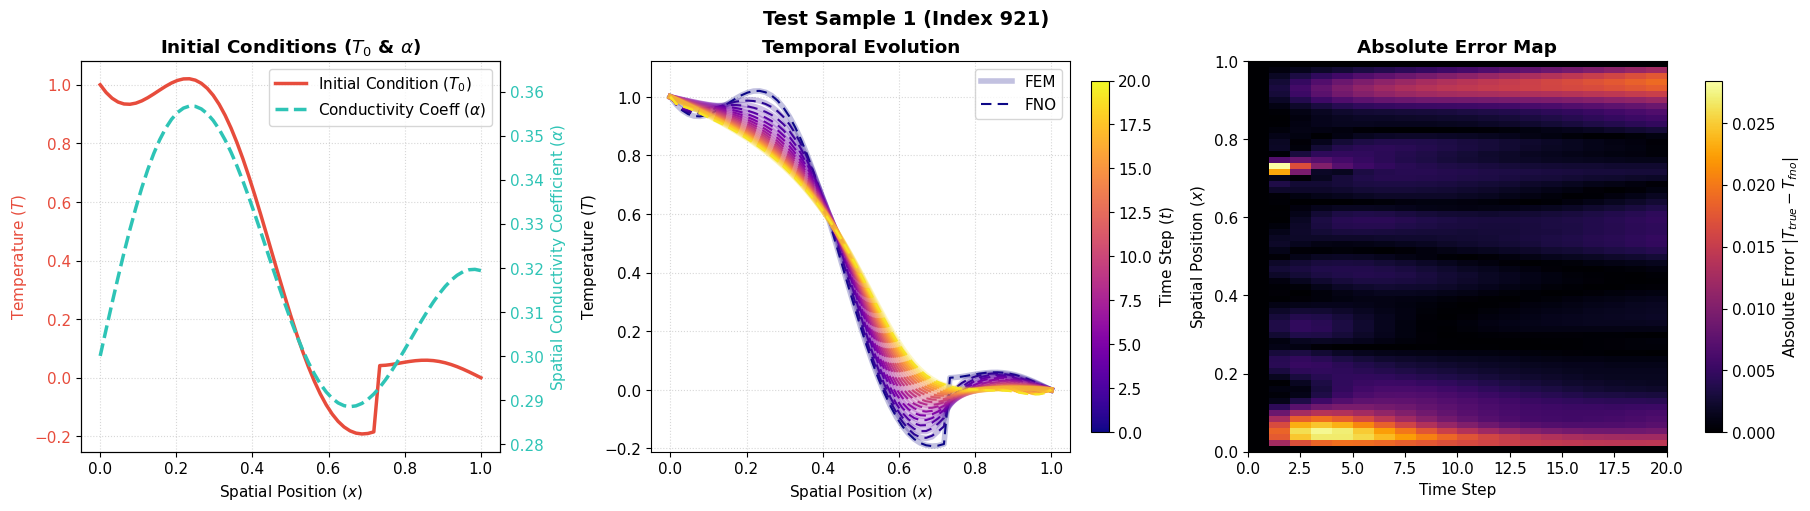

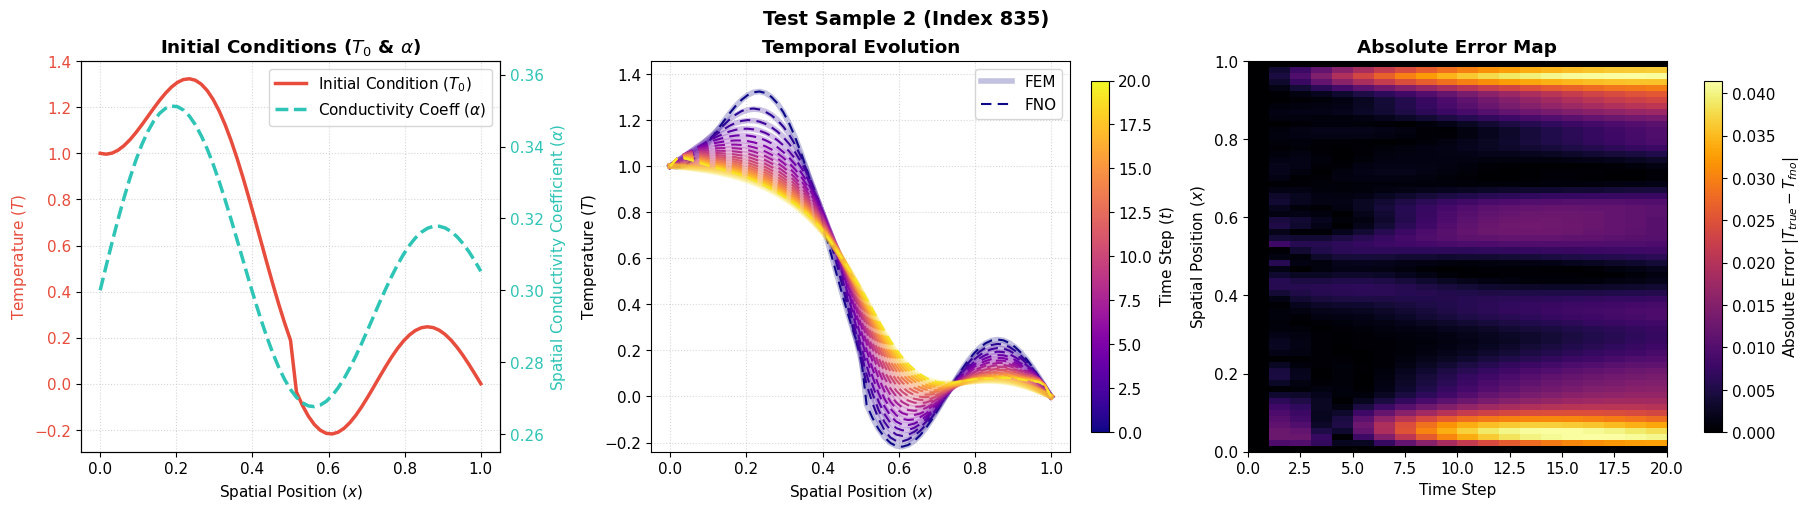

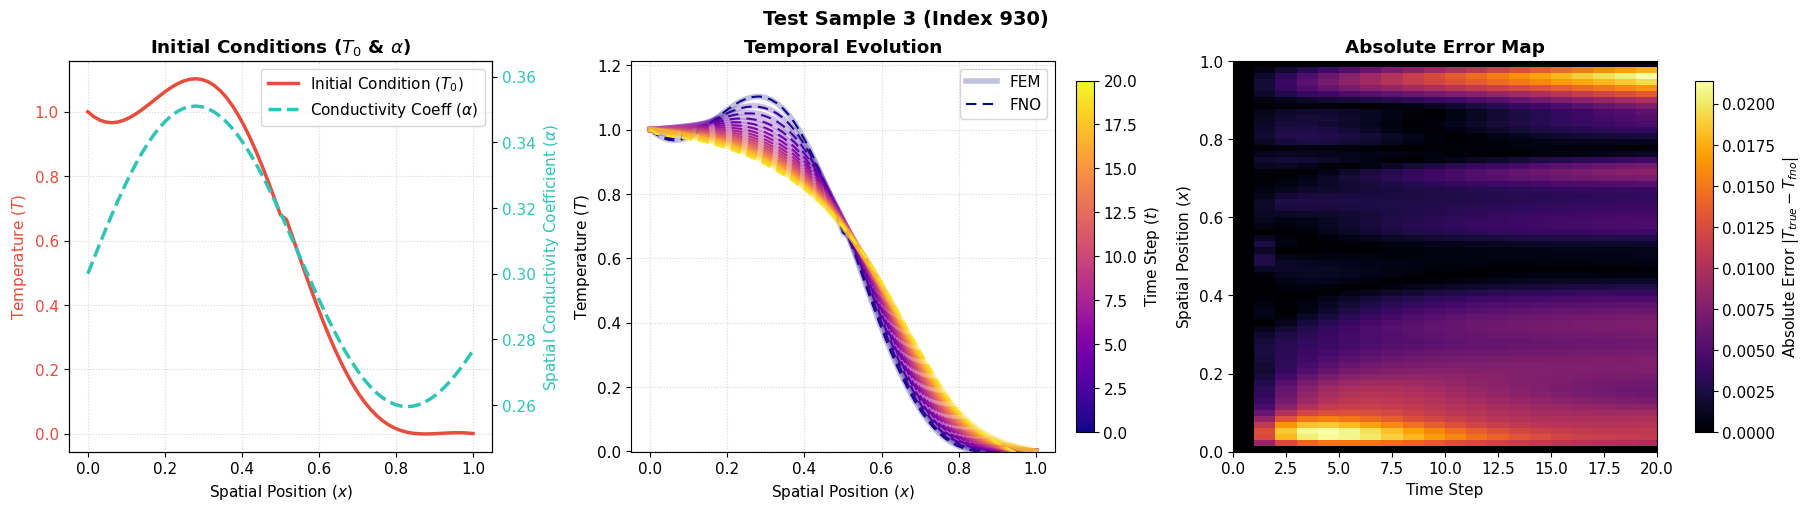

In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. RANDOM TEST SELECTION ---
NUM_TEST_SAMPLES = 3  # How many random samples to visualize
test_key = jax.random.PRNGKey(42)  # Change seed for different random samples

# Define the pool (only indices the model hasn't seen during training)
test_pool = jnp.arange(TRAIN_SAMPLES, N_SAMPLES)

# Choose random indices from the test pool
test_indices = jax.random.choice(test_key, test_pool, shape=(NUM_TEST_SAMPLES,), replace=False)

print(f"Randomly selected test indices: {test_indices}")

cmap = plt.get_cmap('plasma')

# --- 2. EVALUATION & VISUALIZATION LOOP ---
for i, test_idx in enumerate(test_indices):
    # Retrieve data for this random index
    T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]
    
    # Generate trajectories (Using local scope functions)
    true_traj = physics.fem_rollout(T0_test, alpha_test, MAX_STEPS-1)
    fno_pred = rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)
    fno_traj = jnp.vstack([T0_test, fno_pred])
    error_traj = jnp.abs(true_traj - fno_traj)
    
    # Create Figure: 1 Row, 3 Columns using constrained layout to prevent overlap warnings
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")
    
    # --- COL 1: INITIAL TEMPERATURE & MATERIAL PROFILE (TWIN Y-AXIS) ---
    # Primary axis for Temperature
    line1 = ax1.plot(GRID, T0_test, color='#e74c3c', lw=2.5, label="Initial Condition ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#e74c3c')
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Create twin axis for Spatial Conductivity Coefficient (Alpha)
    ax1_twin = ax1.twinx()
    line2 = ax1_twin.plot(GRID, alpha_test, color='#2ec4b6', lw=2.5, ls='--', label="Conductivity Coeff ($\\alpha$)")
    ax1_twin.set_ylabel("Spatial Conductivity Coefficient ($\\alpha$)", color='#2ec4b6')
    ax1_twin.tick_params(axis='y', labelcolor='#2ec4b6')
    
    # Scale secondary axis limits cleanly to fit the dynamic alpha range
    alpha_min, alpha_max = jnp.min(alpha_test), jnp.max(alpha_test)
    alpha_range = abs(alpha_max - alpha_min) if alpha_max != alpha_min else float(alpha_max) * 0.1
    ax1_twin.set_ylim(float(alpha_min) - alpha_range * 0.15, float(alpha_max) + alpha_range * 0.15)
    
    # Combine legends from both axes into one
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")
    
    ax1.set_title("Initial Conditions ($T_0$ & $\\alpha$)", fontweight='bold')
    
    # --- COL 2: TEMPERATURE EVOLUTION (LINE PLOTS) ---
    plot_steps = range(0, MAX_STEPS, 1)  # Plotting every step
    for t in plot_steps:
        color = cmap(t / MAX_STEPS)
        ax2.plot(GRID, true_traj[t], color=color, alpha=0.25, lw=4, label="FEM" if t==0 else "")
        ax2.plot(GRID, fno_traj[t], color=color, ls=(0, (5, 3)), lw=1.5, label="FNO" if t==0 else "")
        
    ax2.set_title("Temporal Evolution", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)")
    ax2.set_ylabel("Temperature ($T$)")
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # Dynamic Y-Limit for Temperature
    y_min, y_max = jnp.min(true_traj), jnp.max(true_traj)
    ax2.set_ylim(y_min - abs(y_min)*0.1, y_max + abs(y_max)*0.1)

    # Dedicated Colorbar for Evolution lines
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9)
    cbar2.set_label('Time Step ($t$)')

    # --- COL 3: ERROR HEATMAP ---
    im3 = ax3.imshow(error_traj.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Position ($x$)")
    
    # Dedicated Colorbar for the Heatmap
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9)
    cbar3.set_label('Absolute Error $|T_{true} - T_{fno}|$')

    fig.suptitle(f"Test Sample {i+1} (Index {test_idx})", fontsize=14, fontweight='bold')
    plt.show()

Analyzing Scenario: Top-Hat Pulse...


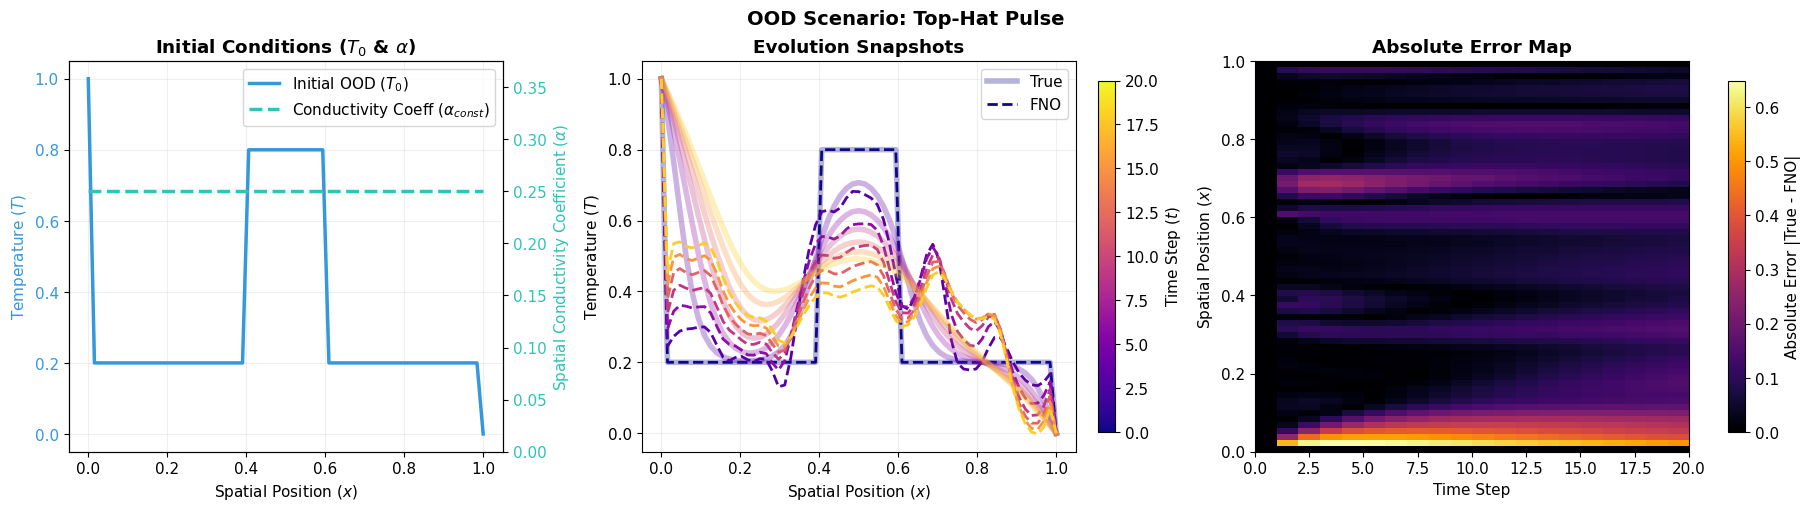

Analyzing Scenario: Sawtooth...


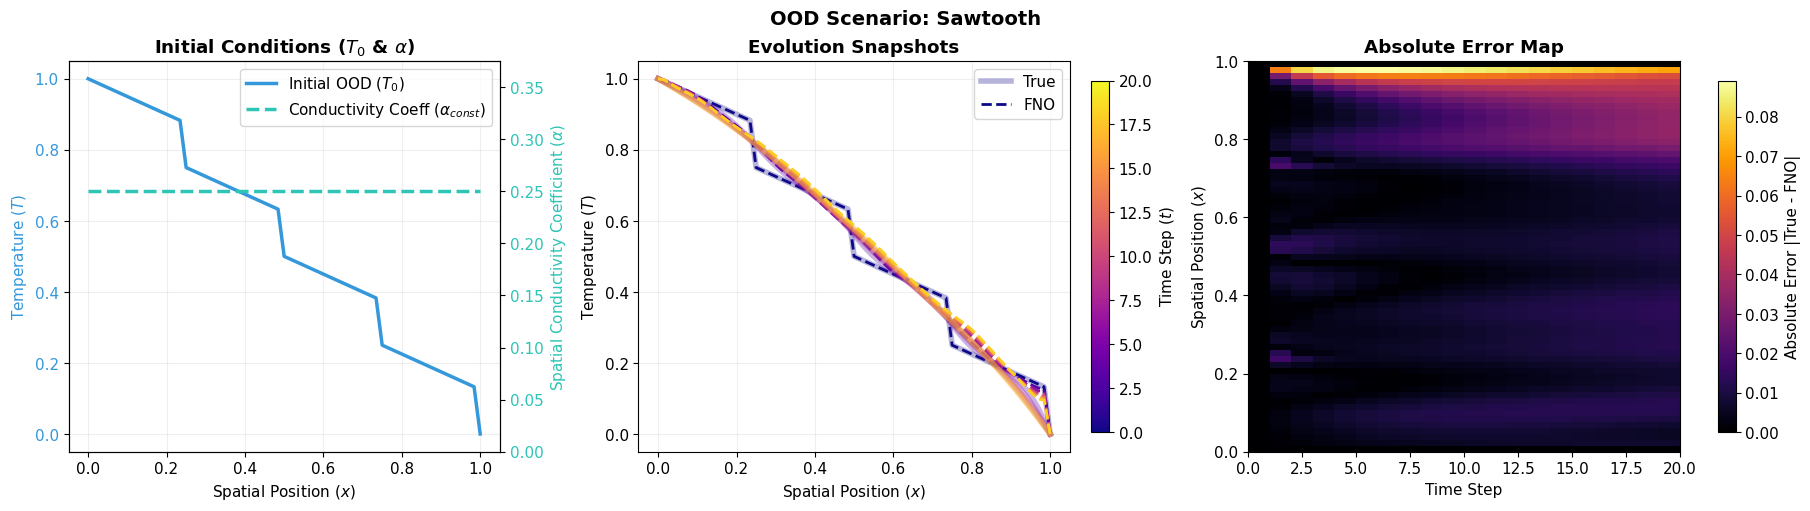

Analyzing Scenario: High-Freq Sine...


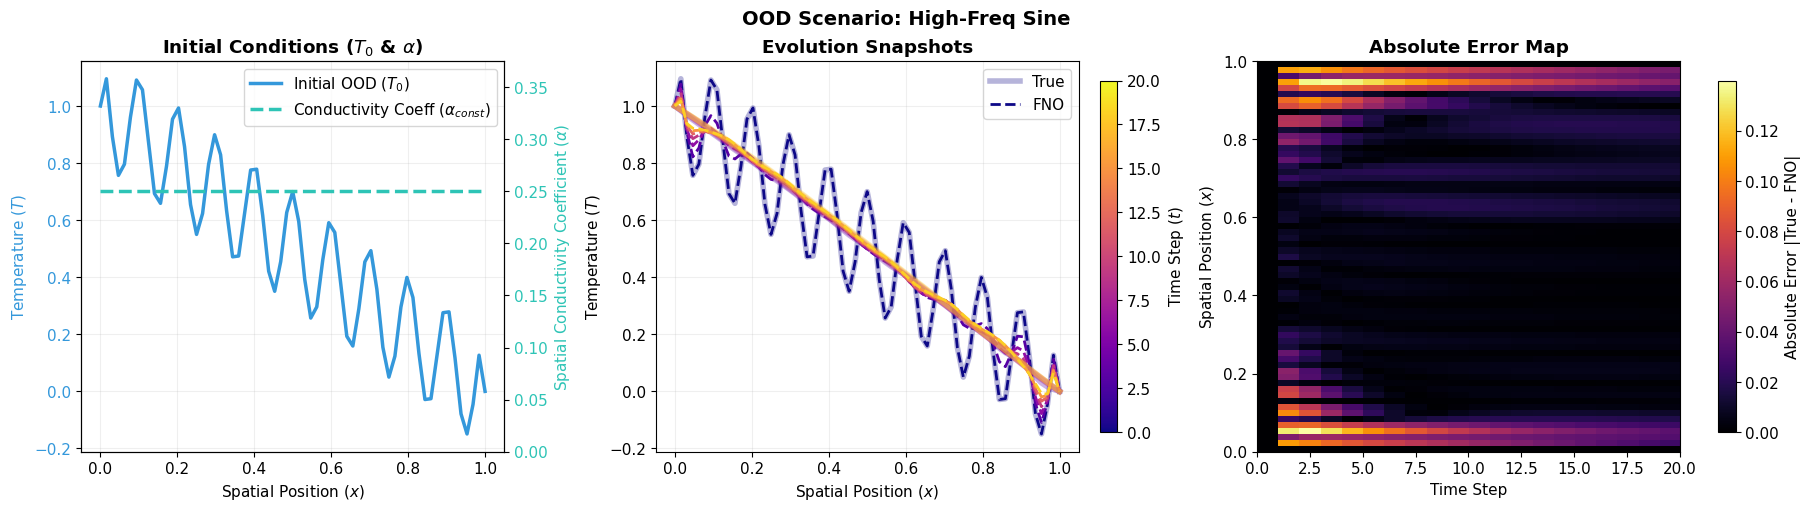

Analyzing Scenario: Double Staircase...


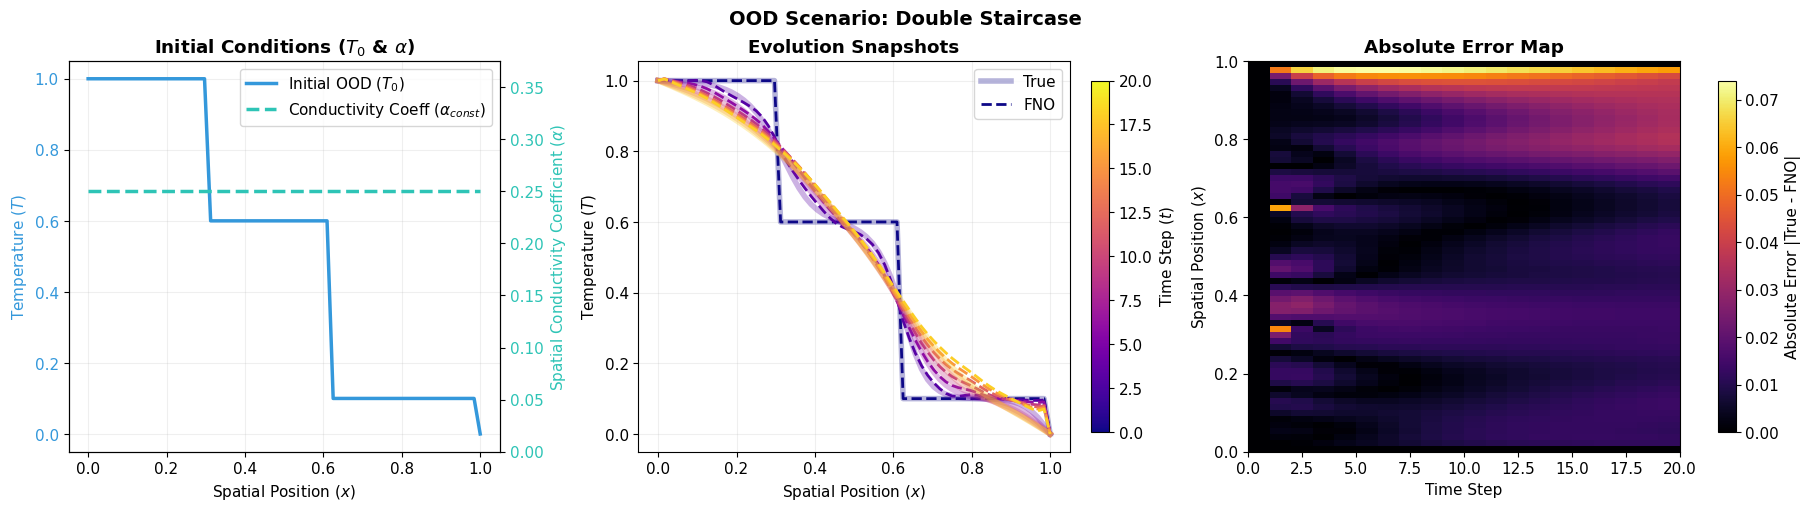

Analyzing Scenario: Exponential Spike...


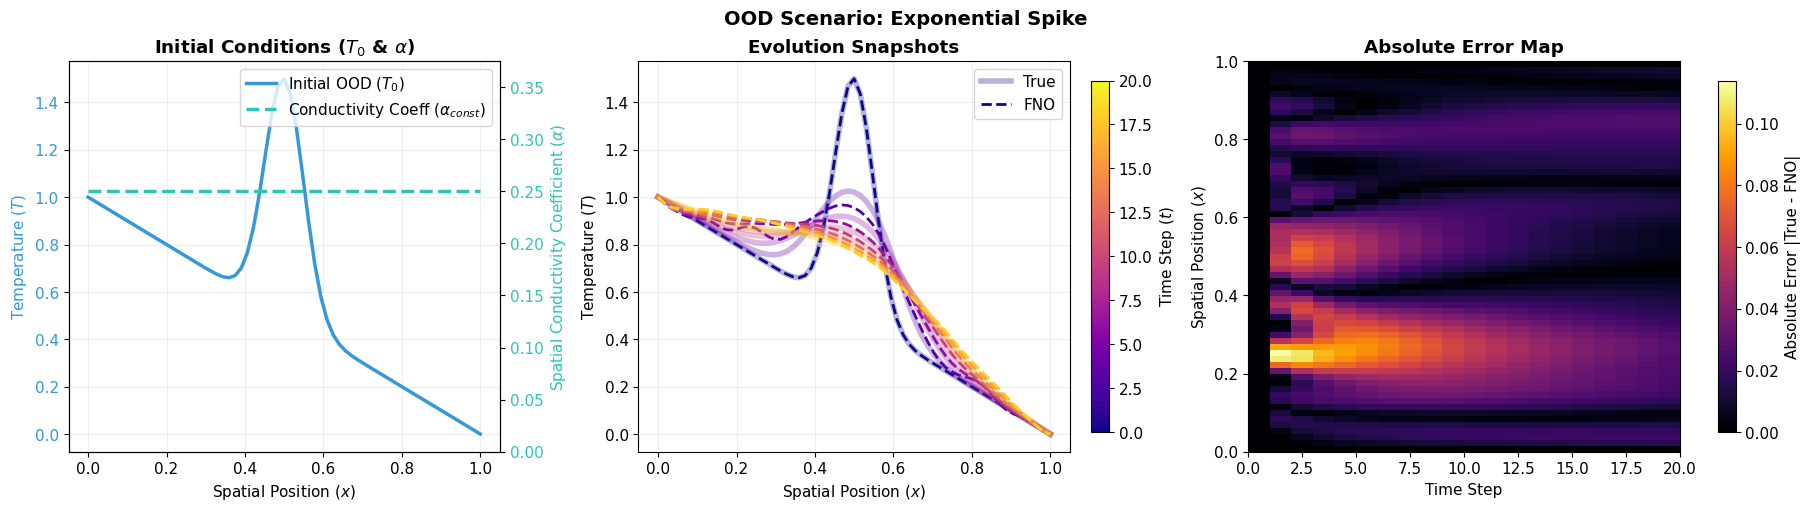

In [42]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Define OOD Scenarios
ood_scenarios = {
    "Top-Hat Pulse": jnp.where((GRID > 0.4) & (GRID < 0.6), 0.8, 0.2),
    "Sawtooth": (1.0 - GRID + 0.5 * (GRID % 0.25)),
    "High-Freq Sine": (jnp.cos(20 * jnp.pi * GRID) * 0.2 + (1.0 - GRID)),
    "Double Staircase": jnp.zeros(N_NODES).at[:20].set(1.0).at[20:40].set(0.6).at[40:].set(0.1),
    "Exponential Spike": (jnp.exp(-((GRID - 0.5)**2) / 0.005) + (1.0 - GRID))
}

# Apply boundary conditions
for name in ood_scenarios:
    ood_scenarios[name] = ood_scenarios[name].at[0].set(1.0).at[-1].set(0.0)

alpha_const = jnp.full((N_NODES,), 0.25)
cmap = plt.get_cmap('plasma')

# 2. Individual Plotting Loop
for name, T0 in ood_scenarios.items():
    print(f"Analyzing Scenario: {name}...")
    
    # --- Data Generation ---
    def fem_step_iter(T_curr, _): 
        val = physics.solve_transient_fem_step(T_curr, alpha_const)
        return val, val
    _, true_history = jax.lax.scan(fem_step_iter, T0, None, length=MAX_STEPS-1)
    true_traj = jnp.vstack([T0, true_history])
    
    fno_traj = jnp.vstack([T0, rollout_fno(params, T0, alpha_const, MAX_STEPS-1)])
    error_map = jnp.abs(true_traj - fno_traj)

    # --- Visualization: 1 Row, 3 Columns ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")
    
    # --- COL 1: INITIAL TEMPERATURE & MATERIAL PROFILE (TWIN Y-AXIS) ---
    # Primary Axis: Exotic OOD Temperature Profile
    line1 = ax1.plot(GRID, T0, color='#3498db', lw=2.5, label="Initial OOD ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#3498db')
    ax1.tick_params(axis='y', labelcolor='#3498db')
    ax1.grid(True, alpha=0.2)
    
    # Secondary Axis: Constant Material Profile (Clean horizontal line instead of fill)
    ax1_twin = ax1.twinx()
    line2 = ax1_twin.plot(GRID, alpha_const, color='#2ec4b6', lw=2.5, ls='--', label="Conductivity Coeff ($\\alpha_{const}$)")
    ax1_twin.set_ylabel("Spatial Conductivity Coefficient ($\\alpha$)", color='#2ec4b6')
    ax1_twin.tick_params(axis='y', labelcolor='#2ec4b6')
    
    # Force the right axis limits so 0.25 sits in a clean, non-inflated window
    alpha_val = float(alpha_const[0])
    ax1_twin.set_ylim(0.0, alpha_val * 1.5)  # Sets bounds from 0.0 to 0.375
    
    # Update legend to pull from line objects instead of the old fill handles
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")
    
    ax1.set_title("Initial Conditions ($T_0$ & $\\alpha$)", fontweight='bold')

    # --- COL 2: TEMPERATURE SNAPSHOTS ---
    for t in range(0, MAX_STEPS, MAX_STEPS // 6):  # Plot 6 representative snapshots
        color = cmap(t / MAX_STEPS)
        ax2.plot(GRID, true_traj[t], color=color, alpha=0.3, lw=4, label="True" if t==0 else "")
        ax2.plot(GRID, fno_traj[t], color=color, ls='--', lw=2, label="FNO" if t==0 else "")
    
    ax2.set_title("Evolution Snapshots", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)")
    ax2.set_ylabel("Temperature ($T$)")
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.2)

    # Dedicated Colorbar for Evolution snapshots
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9)
    cbar2.set_label('Time Step ($t$)')

    # --- COL 3: ERROR HEATMAP ---
    im3 = ax3.imshow(error_map.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Position ($x$)")
    
    # Dedicated Colorbar for Heatmap
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9)
    cbar3.set_label('Absolute Error |True - FNO|')
    
    fig.suptitle(f"OOD Scenario: {name}", fontsize=14, fontweight='bold')
    plt.show()